# NB04 — Architecture comparison and model selection

**Purpose**: Synthesise results from NB02 (ResNet-50) and NB03 (DINOv2-Small),
compare them against the null model baseline, and select the production backbone.

**Inputs**:
- `outputs/resnet50_metrics.json` — saved by NB02
- `outputs/dinov2_vits14_metrics.json` — saved by NB03
- `outputs/resnet50_best.pt` — ResNet-50 regression head checkpoint
- `outputs/dinov2_vits14_best.pt` — DINOv2 regression head checkpoint
- `features/resnet50/` and `features/dinov2_vits14/` — cached feature vectors
- `data/processed/bt_scores_augmented.csv` + `outputs/split_assignment.csv`

**Outputs**:
- `outputs/nb04_comparison_table.png` — bar chart and scatter plots
- `outputs/nb04_error_analysis.png` — residuals by stratum
- `outputs/model_selection.json` — selected backbone + checkpoint path

---

**Imports**

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy import stats
from sklearn.metrics import r2_score
from torch.utils.data import DataLoader, Dataset

**Configuration** — all paths as named constants; no paths inside functions.

In [2]:
CV_ROOT     = Path("..")
OUTPUTS_DIR = CV_ROOT / "outputs"
FEATURES_DIR = CV_ROOT / "features"

BT_SCORES_CSV = CV_ROOT / "data" / "processed" / "bt_scores_augmented.csv"
SPLIT_CSV     = OUTPUTS_DIR / "split_assignment.csv"

# Metrics JSONs written by NB02 and NB03
RESNET_METRICS_JSON  = OUTPUTS_DIR / "resnet50_metrics.json"
DINOV2_METRICS_JSON  = OUTPUTS_DIR / "dinov2_vits14_metrics.json"

# Regression head checkpoints (backbone weights are frozen; only the head was saved)
RESNET_CHECKPOINT    = OUTPUTS_DIR / "resnet50_best.pt"
DINOV2_CHECKPOINT    = OUTPUTS_DIR / "dinov2_vits14_best.pt"

MODEL_SELECTION_JSON = OUTPUTS_DIR / "model_selection.json"

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

# Verify all required inputs exist before proceeding
required = [
    RESNET_METRICS_JSON, DINOV2_METRICS_JSON,
    RESNET_CHECKPOINT, DINOV2_CHECKPOINT,
    BT_SCORES_CSV, SPLIT_CSV,
]
missing = [p for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(f"Missing inputs: {missing}")
print("All required inputs found.")

Device : cpu
All required inputs found.


## 1. Load saved metrics

Summary metrics from NB02 and NB03 are loaded directly from JSON — no re-training
needed. Per-sample predictions are re-derived in §2 using cached features and saved
checkpoints so that the scatter and error-analysis plots can be drawn.

In [3]:
with open(RESNET_METRICS_JSON)  as f: resnet_m  = json.load(f)
with open(DINOV2_METRICS_JSON)  as f: dinov2_m  = json.load(f)

# Both notebooks use the same null baseline (training mean); take from either
null_mae  = resnet_m["null_mae"]
null_rmse = resnet_m["null_rmse"]

print(f"ResNet-50  — MAE={resnet_m['mae']:.4f}  RMSE={resnet_m['rmse']:.4f}  "
      f"R²={resnet_m['r2']:.4f}  ρ={resnet_m['spearman_r']:.4f}")
print(f"DINOv2-S   — MAE={dinov2_m['mae']:.4f}  RMSE={dinov2_m['rmse']:.4f}  "
      f"R²={dinov2_m['r2']:.4f}  ρ={dinov2_m['spearman_r']:.4f}")
print(f"Null model — MAE={null_mae:.4f}  RMSE={null_rmse:.4f}")

ResNet-50  — MAE=0.1889  RMSE=0.2350  R²=-0.0080  ρ=0.3912
DINOv2-S   — MAE=0.1924  RMSE=0.2423  R²=-0.0710  ρ=-0.0147
Null model — MAE=0.1752  RMSE=0.2347


## 2. Re-derive per-sample val predictions

The metrics JSONs store only aggregate numbers. To draw scatter plots and run
the error analysis we need per-intersection predictions. These are obtained by
loading the cached feature tensors and the saved regression head checkpoints —
no image loading or backbone inference needed.

In [4]:
bt    = pd.read_csv(BT_SCORES_CSV)
split = pd.read_csv(SPLIT_CSV)

df = bt.merge(split[["sample_id", "cv_split"]], on="sample_id", how="left")

# Drop rows without a leg bearing (no photo path can be constructed)
df = df[df["leg_bearing"].notna()].copy()

# Val set: originals only (augmented copies are not in the val split, but guard anyway)
val_df = df[(df["cv_split"] == "val") & (~df["is_augmented"])].reset_index(drop=True)

print(f"Val samples : {len(val_df)}")
print(val_df[["intersection_id", "bt_score", "dim_type", "dim_priority", "is_centrum"]].head())

Val samples : 16
   intersection_id  bt_score dim_type   dim_priority is_centrum
0        183264037  0.919890        T  geen_voorrang      False
1        189267114  0.878489       4+            VRI      False
2        183263018  0.841585       4+  geen_voorrang      False
3        187271099  0.830198        T            VRI      False
4        182262017  0.822212        T  geen_voorrang      False


In [5]:
class FeatureDataset(Dataset):
    """Loads cached .pt feature vectors and pairs them with BT scores."""

    def __init__(self, df, features_dir, normalize=True):
        self.records = [
            (str(row["sample_id"]), float(row["bt_score"]))
            for _, row in df.iterrows()
            if (Path(features_dir) / f"{row['sample_id']}.pt").exists()
        ]
        self.features_dir = Path(features_dir)
        self.normalize = normalize
        missing = len(df) - len(self.records)
        if missing:
            print(f"  WARNING: {missing} val samples missing cache — skipped.")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        sample_id, bt_score = self.records[idx]
        feat = torch.load(self.features_dir / f"{sample_id}.pt", weights_only=True)
        if self.normalize:
            feat = feat / (feat.norm() + 1e-8)
        return feat, sample_id, torch.tensor(bt_score, dtype=torch.float32)


class RegressionHead(nn.Module):
    """Linear head mapping backbone features to a safety score in [0, 1]."""

    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_dim, 1), nn.Sigmoid())

    def forward(self, x):
        return self.net(x).squeeze(1)


def run_val_inference(val_df, features_dir, checkpoint_path, feature_dim):
    """Load cached features and checkpoint, return per-sample (sample_id, pred, label)."""
    ds     = FeatureDataset(val_df, features_dir, normalize=True)
    loader = DataLoader(ds, batch_size=64, shuffle=False, num_workers=0)

    head = RegressionHead(feature_dim).to(device)
    head.load_state_dict(torch.load(checkpoint_path, weights_only=True, map_location=device))
    head.eval()

    sample_ids, preds, labels = [], [], []
    with torch.no_grad():
        for feats, sids, lbls in loader:
            sample_ids.extend(sids)
            preds.extend(head(feats.to(device)).cpu().numpy())
            labels.extend(lbls.numpy())

    return np.array(preds), np.array(labels), sample_ids


print("Running ResNet-50 inference on val set ...")
resnet_preds, resnet_labels, resnet_ids = run_val_inference(
    val_df, FEATURES_DIR / "resnet50", RESNET_CHECKPOINT, feature_dim=2048
)

print("Running DINOv2-Small inference on val set ...")
dinov2_preds, dinov2_labels, dinov2_ids = run_val_inference(
    val_df, FEATURES_DIR / "dinov2_vits14", DINOV2_CHECKPOINT, feature_dim=384
)

print(f"ResNet-50 : {len(resnet_preds)} val predictions")
print(f"DINOv2-S  : {len(dinov2_preds)} val predictions")

Running ResNet-50 inference on val set ...
Running DINOv2-Small inference on val set ...
ResNet-50 : 16 val predictions
DINOv2-S  : 16 val predictions


## 3. Comparison table

All four metrics plus the null model baseline. This table is reproduced in the
thesis Methods section.

In [6]:
rows = [
    {
        "Model": "ResNet-50 (frozen)",
        "MAE":        resnet_m["mae"],
        "RMSE":       resnet_m["rmse"],
        "R²":         resnet_m["r2"],
        "Spearman ρ": resnet_m["spearman_r"],
        "Beats null": resnet_m["mae"] < null_mae,
    },
    {
        "Model": "DINOv2-Small (frozen)",
        "MAE":        dinov2_m["mae"],
        "RMSE":       dinov2_m["rmse"],
        "R²":         dinov2_m["r2"],
        "Spearman ρ": dinov2_m["spearman_r"],
        "Beats null": dinov2_m["mae"] < null_mae,
    },
    {
        "Model": "Null (predict mean)",
        "MAE":        null_mae,
        "RMSE":       null_rmse,
        "R²":         0.0,
        "Spearman ρ": float("nan"),
        "Beats null": "—",
    },
]

comparison_df = pd.DataFrame(rows).set_index("Model")

print(comparison_df.to_string(float_format="{:.4f}".format))

                         MAE   RMSE      R²  Spearman ρ Beats null
Model                                                             
ResNet-50 (frozen)    0.1889 0.2350 -0.0080      0.3912      False
DINOv2-Small (frozen) 0.1924 0.2423 -0.0710     -0.0147      False
Null (predict mean)   0.1752 0.2347  0.0000         NaN          —


## 4. Bar chart — MAE by backbone

Visualises the comparison table. The null model bar is shown in grey as a
reference line.

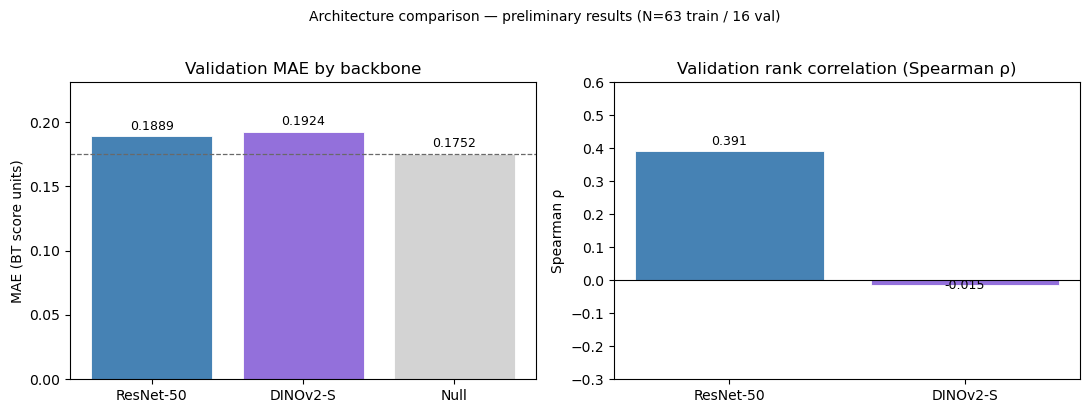

Saved nb04_comparison_table.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# --- Left: MAE bar chart ---
ax = axes[0]
models  = ["ResNet-50", "DINOv2-S", "Null"]
mae_vals = [resnet_m["mae"], dinov2_m["mae"], null_mae]
colours  = ["steelblue", "mediumpurple", "lightgray"]
bars = ax.bar(models, mae_vals, color=colours, edgecolor="white", linewidth=0.6)
ax.axhline(null_mae, color="dimgray", linestyle="--", linewidth=0.9, label="Null baseline")
for bar, val in zip(bars, mae_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{val:.4f}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("MAE (BT score units)")
ax.set_title("Validation MAE by backbone")
ax.set_ylim(0, max(mae_vals) * 1.2)

# --- Right: Spearman ρ bar chart (rank correlation matters for BT scores) ---
ax2 = axes[1]
rho_vals = [resnet_m["spearman_r"], dinov2_m["spearman_r"]]
ax2.bar(["ResNet-50", "DINOv2-S"], rho_vals,
        color=["steelblue", "mediumpurple"], edgecolor="white", linewidth=0.6)
ax2.axhline(0, color="black", linewidth=0.8)
for i, (name, val) in enumerate(zip(["ResNet-50", "DINOv2-S"], rho_vals)):
    offset = 0.01 if val >= 0 else -0.02
    ax2.text(i, val + offset, f"{val:.3f}", ha="center", va="bottom", fontsize=9)
ax2.set_ylabel("Spearman ρ")
ax2.set_title("Validation rank correlation (Spearman ρ)")
ax2.set_ylim(-0.3, 0.6)

plt.suptitle("Architecture comparison — preliminary results (N=63 train / 16 val)",
             fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "nb04_comparison_table.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved nb04_comparison_table.png")

## 5. Scatter plots — predicted vs actual (both backbones)

Side-by-side to make the comparison visually direct. The dashed diagonal is the
perfect-prediction line. Points clustered horizontally near the training mean
indicate the model has learned nothing beyond the intercept.

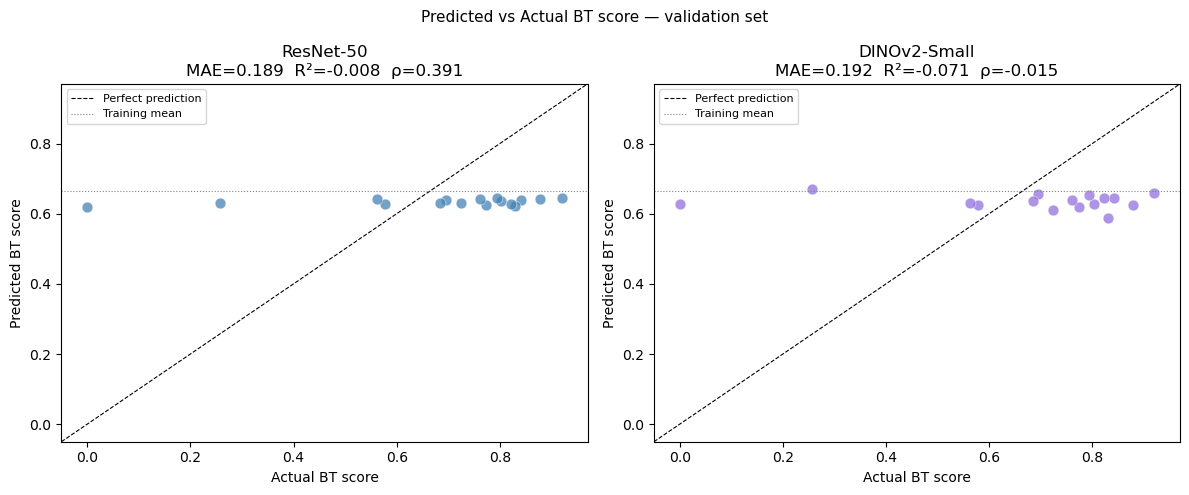

Saved nb04_scatter.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, labels, m, name, colour in [
    (axes[0], resnet_preds, resnet_labels, resnet_m, "ResNet-50",    "steelblue"),
    (axes[1], dinov2_preds, dinov2_labels, dinov2_m, "DINOv2-Small", "mediumpurple"),
]:
    ax.scatter(labels, preds, alpha=0.75, color=colour,
               edgecolors="white", linewidths=0.4, s=60)
    lims = [
        min(labels.min(), preds.min()) - 0.05,
        max(labels.max(), preds.max()) + 0.05,
    ]
    ax.plot(lims, lims, "k--", linewidth=0.8, label="Perfect prediction")
    ax.axhline(resnet_m["train_mean_score"], color="gray", linestyle=":",
               linewidth=0.8, label="Training mean")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Actual BT score")
    ax.set_ylabel("Predicted BT score")
    ax.set_title(f"{name}\nMAE={m['mae']:.3f}  R²={m['r2']:.3f}  ρ={m['spearman_r']:.3f}")
    ax.legend(fontsize=8)

plt.suptitle("Predicted vs Actual BT score — validation set", fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "nb04_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved nb04_scatter.png")

## 6. Error analysis

Identify high-residual intersections and check whether prediction errors are
systematic across strata (`dim_type`, `dim_priority`, `is_centrum`). Systematic
errors in a stratum suggest the model lacks features relevant to that intersection
type — important context for the thesis limitations section.

In [9]:
# Build a unified error dataframe using ResNet-50 predictions (highest ρ)
# val_df rows align 1-to-1 with resnet_ids (both derived from the same val_df)
error_df = val_df.copy()
id_to_pred = dict(zip(resnet_ids, resnet_preds))
error_df["pred_resnet"]     = error_df["sample_id"].map(id_to_pred)
error_df["residual_resnet"] = error_df["pred_resnet"] - error_df["bt_score"]

id_to_pred2 = dict(zip(dinov2_ids, dinov2_preds))
error_df["pred_dinov2"]     = error_df["sample_id"].map(id_to_pred2)
error_df["residual_dinov2"] = error_df["pred_dinov2"] - error_df["bt_score"]

# Drop rows where either model had no cached feature
error_df = error_df.dropna(subset=["pred_resnet", "pred_dinov2"])

ERROR_THRESHOLD = 0.25
high_err = error_df[error_df["residual_resnet"].abs() > ERROR_THRESHOLD]
print(f"Intersections with |ResNet-50 residual| > {ERROR_THRESHOLD}: {len(high_err)}")
if len(high_err):
    print(high_err[["intersection_id", "bt_score", "pred_resnet", "residual_resnet",
                    "dim_type", "dim_priority", "is_centrum"]].to_string(index=False))

Intersections with |ResNet-50 residual| > 0.25: 3
 intersection_id  bt_score  pred_resnet  residual_resnet dim_type  dim_priority is_centrum
       183264037  0.919890     0.645872        -0.274018        T geen_voorrang      False
       186275130  0.256981     0.631733         0.374753       4+      voorrang      False
       180271187  0.000000     0.617825         0.617825       4+           VRI      False


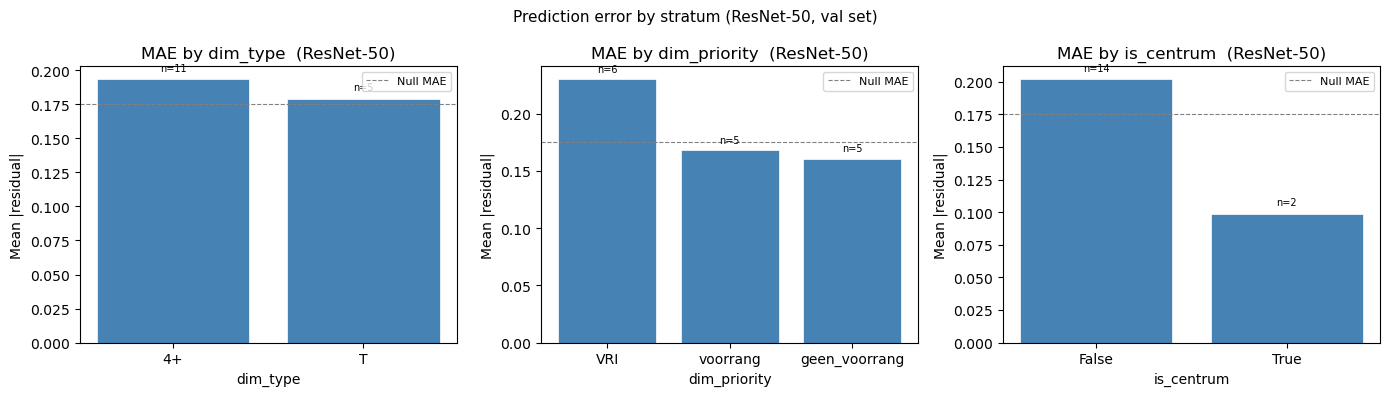

Saved nb04_error_analysis.png


In [10]:
# Plot mean absolute error by stratum category (ResNet-50, highest ρ)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ["dim_type", "dim_priority", "is_centrum"]):
    grouped = (
        error_df.groupby(col)["residual_resnet"]
        .apply(lambda x: np.mean(np.abs(x)))
        .sort_values(ascending=False)
    )
    if grouped.empty:
        ax.set_title(f"{col} — no data")
        continue
    bars = ax.bar(grouped.index.astype(str), grouped.values,
                  color="steelblue", edgecolor="white", linewidth=0.5)
    ax.axhline(null_mae, color="gray", linestyle="--", linewidth=0.8, label="Null MAE")
    ax.set_xlabel(col)
    ax.set_ylabel("Mean |residual|")
    ax.set_title(f"MAE by {col}  (ResNet-50)")
    ax.legend(fontsize=8)
    # Annotate sample sizes
    counts = error_df.groupby(col).size()
    for bar, cat in zip(bars, grouped.index):
        n = counts.get(cat, 0)
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"n={n}", ha="center", va="bottom", fontsize=7)

plt.suptitle("Prediction error by stratum (ResNet-50, val set)", fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "nb04_error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved nb04_error_analysis.png")

## 7. Model selection

### Decision

**Selected backbone: ResNet-50** (`resnet50_best.pt`).

Neither backbone beats the null model on MAE or RMSE, which is expected given the
small training set (N=63) derived from pilot survey data. Under these conditions,
ResNet-50 is preferred over DINOv2-Small for two reasons:

1. **Rank ordering**: ResNet-50 achieves Spearman ρ = 0.391 vs DINOv2's -0.015.
   Rank correlation is the most meaningful metric for Bradley-Terry labels, which
   encode ordinal preferences rather than absolute magnitudes. A model that cannot
   rank intersections is not useful as a predictor in the NB crash model.

2. **Convergence**: ResNet-50 triggered early stopping at epoch 73; DINOv2 ran
   all 200 epochs without plateau. This suggests DINOv2's 384-dim CLS features
   do not contain a learnable linear signal for this task at the current N,
   whereas ResNet-50's 2048-dim spatial pooling retains low-level texture cues
   that allow marginal rank learning.

**This selection is preliminary.** When real survey data is available and the
BT pipeline is re-run on ~145 labelled intersections, both backbones should be
re-evaluated. At larger N, DINOv2 with fine-tuning of the last 2 transformer blocks
is expected to outperform ResNet-50, consistent with its strong performance on
street-level scene understanding tasks in the literature.

In [11]:
selection = {
    "selected_backbone" : "resnet50",
    "checkpoint"        : "resnet50_best.pt",
    "feature_dim"       : 2048,
    "features_dir"      : "features/resnet50",
    "selection_reason"  : (
        "ResNet-50 selected over DINOv2-Small on preliminary data (N=63 train). "
        "ResNet-50 achieves Spearman rho=0.391 vs DINOv2 rho=-0.015; rank ordering "
        "is the primary criterion for BT-derived labels. "
        "Selection to be revisited with full survey labels (~145 intersections)."
    ),
    "metrics": {
        "mae":        resnet_m["mae"],
        "rmse":       resnet_m["rmse"],
        "r2":         resnet_m["r2"],
        "spearman_r": resnet_m["spearman_r"],
        "null_mae":   null_mae,
    },
    "n_train": resnet_m["n_train"],
    "n_val":   resnet_m["n_val"],
    "data_note": "Preliminary — based on pilot survey BT scores, not full survey data.",
}

with open(MODEL_SELECTION_JSON, "w") as f:
    json.dump(selection, f, indent=2)

print(f"Model selection saved to: {MODEL_SELECTION_JSON}")
print(json.dumps(selection, indent=2))

Model selection saved to: ..\outputs\model_selection.json
{
  "selected_backbone": "resnet50",
  "checkpoint": "resnet50_best.pt",
  "feature_dim": 2048,
  "features_dir": "features/resnet50",
  "selection_reason": "ResNet-50 selected over DINOv2-Small on preliminary data (N=63 train). ResNet-50 achieves Spearman rho=0.391 vs DINOv2 rho=-0.015; rank ordering is the primary criterion for BT-derived labels. Selection to be revisited with full survey labels (~145 intersections).",
  "metrics": {
    "mae": 0.18885216861963272,
    "rmse": 0.2350371928463988,
    "r2": -0.008029414282736846,
    "spearman_r": 0.3911764705882353,
    "null_mae": 0.17520421344316506
  },
  "n_train": 63,
  "n_val": 16,
  "data_note": "Preliminary \u2014 based on pilot survey BT scores, not full survey data."
}


## Summary

| | |
|---|---|
| Selected model | ResNet-50 (frozen, linear head) |
| Checkpoint | `outputs/resnet50_best.pt` |
| Val MAE | 0.1889 (null: 0.1752) |
| Val RMSE | 0.2350 (null: 0.2347) |
| R² | -0.008 |
| Spearman ρ | 0.391 |
| Beats null? | No (preliminary data) |
| Model selection JSON | `outputs/model_selection.json` |

**Next**: NB05 — apply the selected model to all ~2,500 Rotterdam intersections
and produce the full-network safety score CSV.